In [58]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import os
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import librosa as lb
import json
import matplotlib.pyplot as plt
from IPython.display import Audio
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

#for dirname, _, filenames in os.walk('/kaggle/input'):
    #for filename in filenames:
        #print(os.path.join(dirname, filename))
import warnings
warnings.filterwarnings("ignore")
# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Exploration of music data

In [3]:
# CONFIGURATION
DATA_ROOT = '/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/genres_stems'
GENRES = ['blues', 'classical', 'country', 'disco', 'hiphop','jazz', 'metal', 'pop', 'reggae', 'rock'] # Make the list of all genres available
STEMS = {'vocals.wav','other.wav','bass.wav','drums.wav'} # Write here stems file name
STEM_KEYS = ['drums', 'vocals', 'bass', 'other']
GENRE_TO_TEST = ''  #Enter genre name to test.
SONG_INDEX = ''     #Enter index as per Q10.

print("✅")

✅


In [5]:
def build_dataset(root_dir, val_split= None, seed=42):
    # Initialize empty dictionaries
    song_list = {g: {s.replace('.wav', ''): [] for s in STEMS} for g in GENRES}
    total_stem_file = 0
    for g in GENRES:
        folder_path = root_dir + '/' + g
        if os.path.exists(folder_path) and os.path.isdir(folder_path):
            for i in range(0,100):
                song_folder = g + '.' + f"{i:05d}"
                for s in STEMS:
                    stem_file_path = folder_path + '/' + song_folder + '/' + s
                    if os.path.exists(stem_file_path):
                        total_stem_file += 1
                        song_list[g][s.replace('.wav', '')].append(stem_file_path)
                    else:
                        print(f"Stem file {s} not exists !")
            
        else:
            print(f"Folder '{g}' not exists !")

    print("Total number of stems music file loaded successfully : ", total_stem_file)
    
    if val_split :
        train_dataset = {g: {s.replace('.wav', ''): [] for s in STEMS} for g in GENRES}
        val_dataset   = {g: {s.replace('.wav', ''): [] for s in STEMS} for g in GENRES}
        def add_to_dict(train_dataset,val_dataset,song_list):
            for g in GENRES:
                for s in STEM_KEYS:
                    for k in index[0:83]:
                        train_dataset[g][s].append(song_list[g][s][k])
                    for k in index[83:]:
                        val_dataset[g][s].append(song_list[g][s][k])
        add_to_dict(train_dataset,val_dataset,song_list)
    
        return train_dataset, val_dataset , song_list
    return song_list

sl = build_dataset(DATA_ROOT)

Total number of stems music file loaded successfully :  4000


In [15]:
# Now `sl` contains all stems file's absolute path as a dictionary `genre`->`stem'->[]
#print(json.dumps(sl,indent=3))

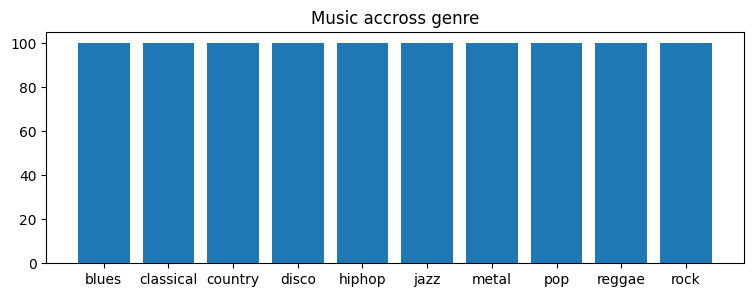

In [17]:
# Checking music distribution accross genre
genre_wise_music_count = []
for key in sl.keys():
    bass_len = len(sl[key]['bass'])
    vocals_len = len(sl[key]['vocals'])
    drums_len = len(sl[key]['drums'])
    other_len = len(sl[key]['other'])
    assert bass_len == vocals_len == drums_len == other_len
    genre_wise_music_count.append((key,bass_len))

genres = [t[0] for t in genre_wise_music_count]  
values = [t[1] for t in genre_wise_music_count]  
fig, axs = plt.subplots(figsize=(9, 3))
axs.bar(genres, values)

axs.set_title('Music accross genre')
plt.show()

> So we can see that every genre has equal number of music files.

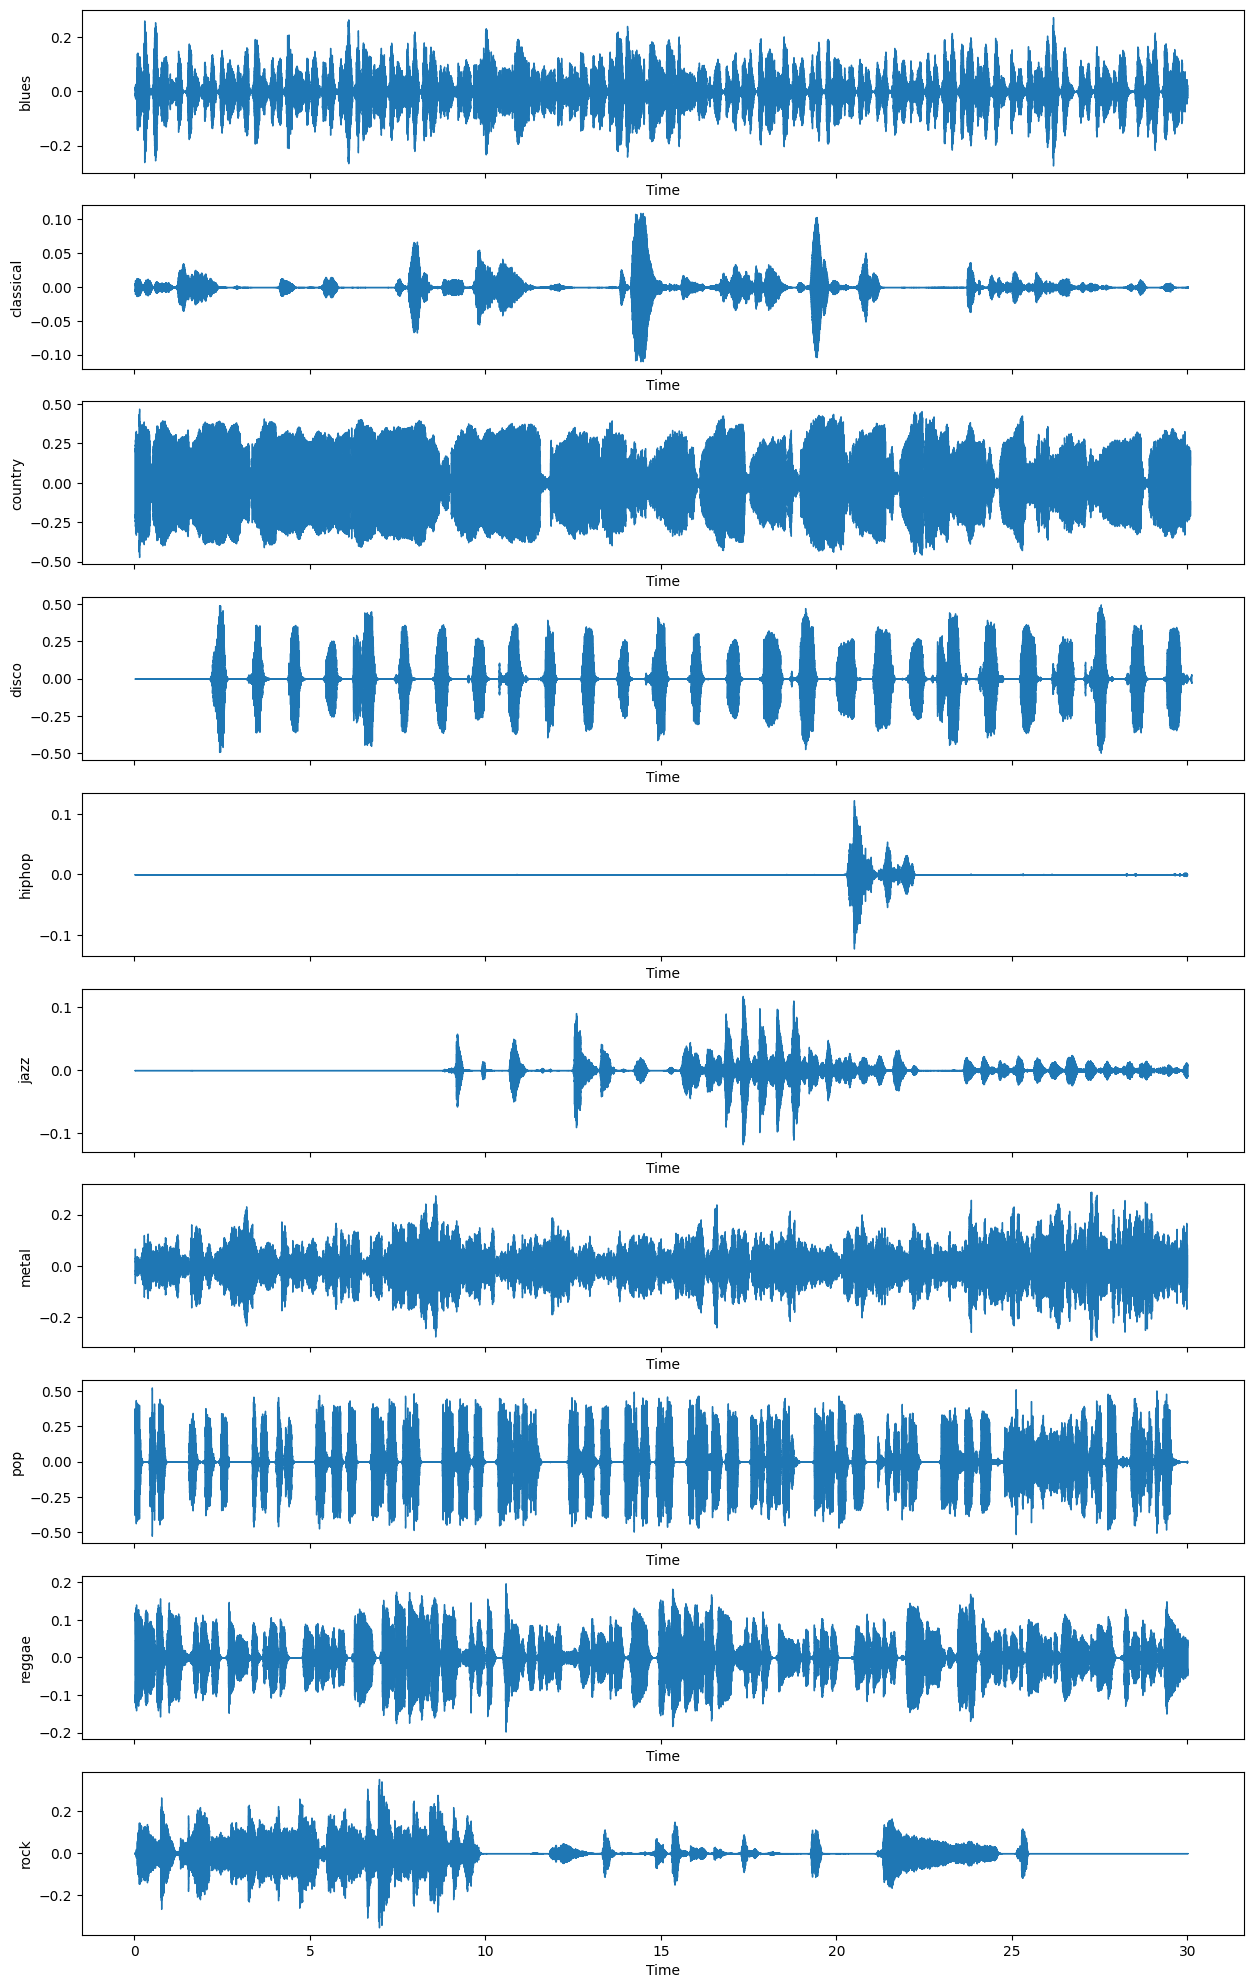

In [27]:
# Genre wise stem file checking - 
def show_wave_form(stem):
    fig,ax = plt.subplots(nrows=10,figsize=(15,25),sharex=True)
    for i,g in enumerate(GENRES):
        y,sr = lb.load(path=sl[g][stem][0],sr=None)
        lb.display.waveshow(y=y,sr=sr,ax=ax[i])
        ax[i].set_ylabel(g)
    plt.show()
show_wave_form('bass')

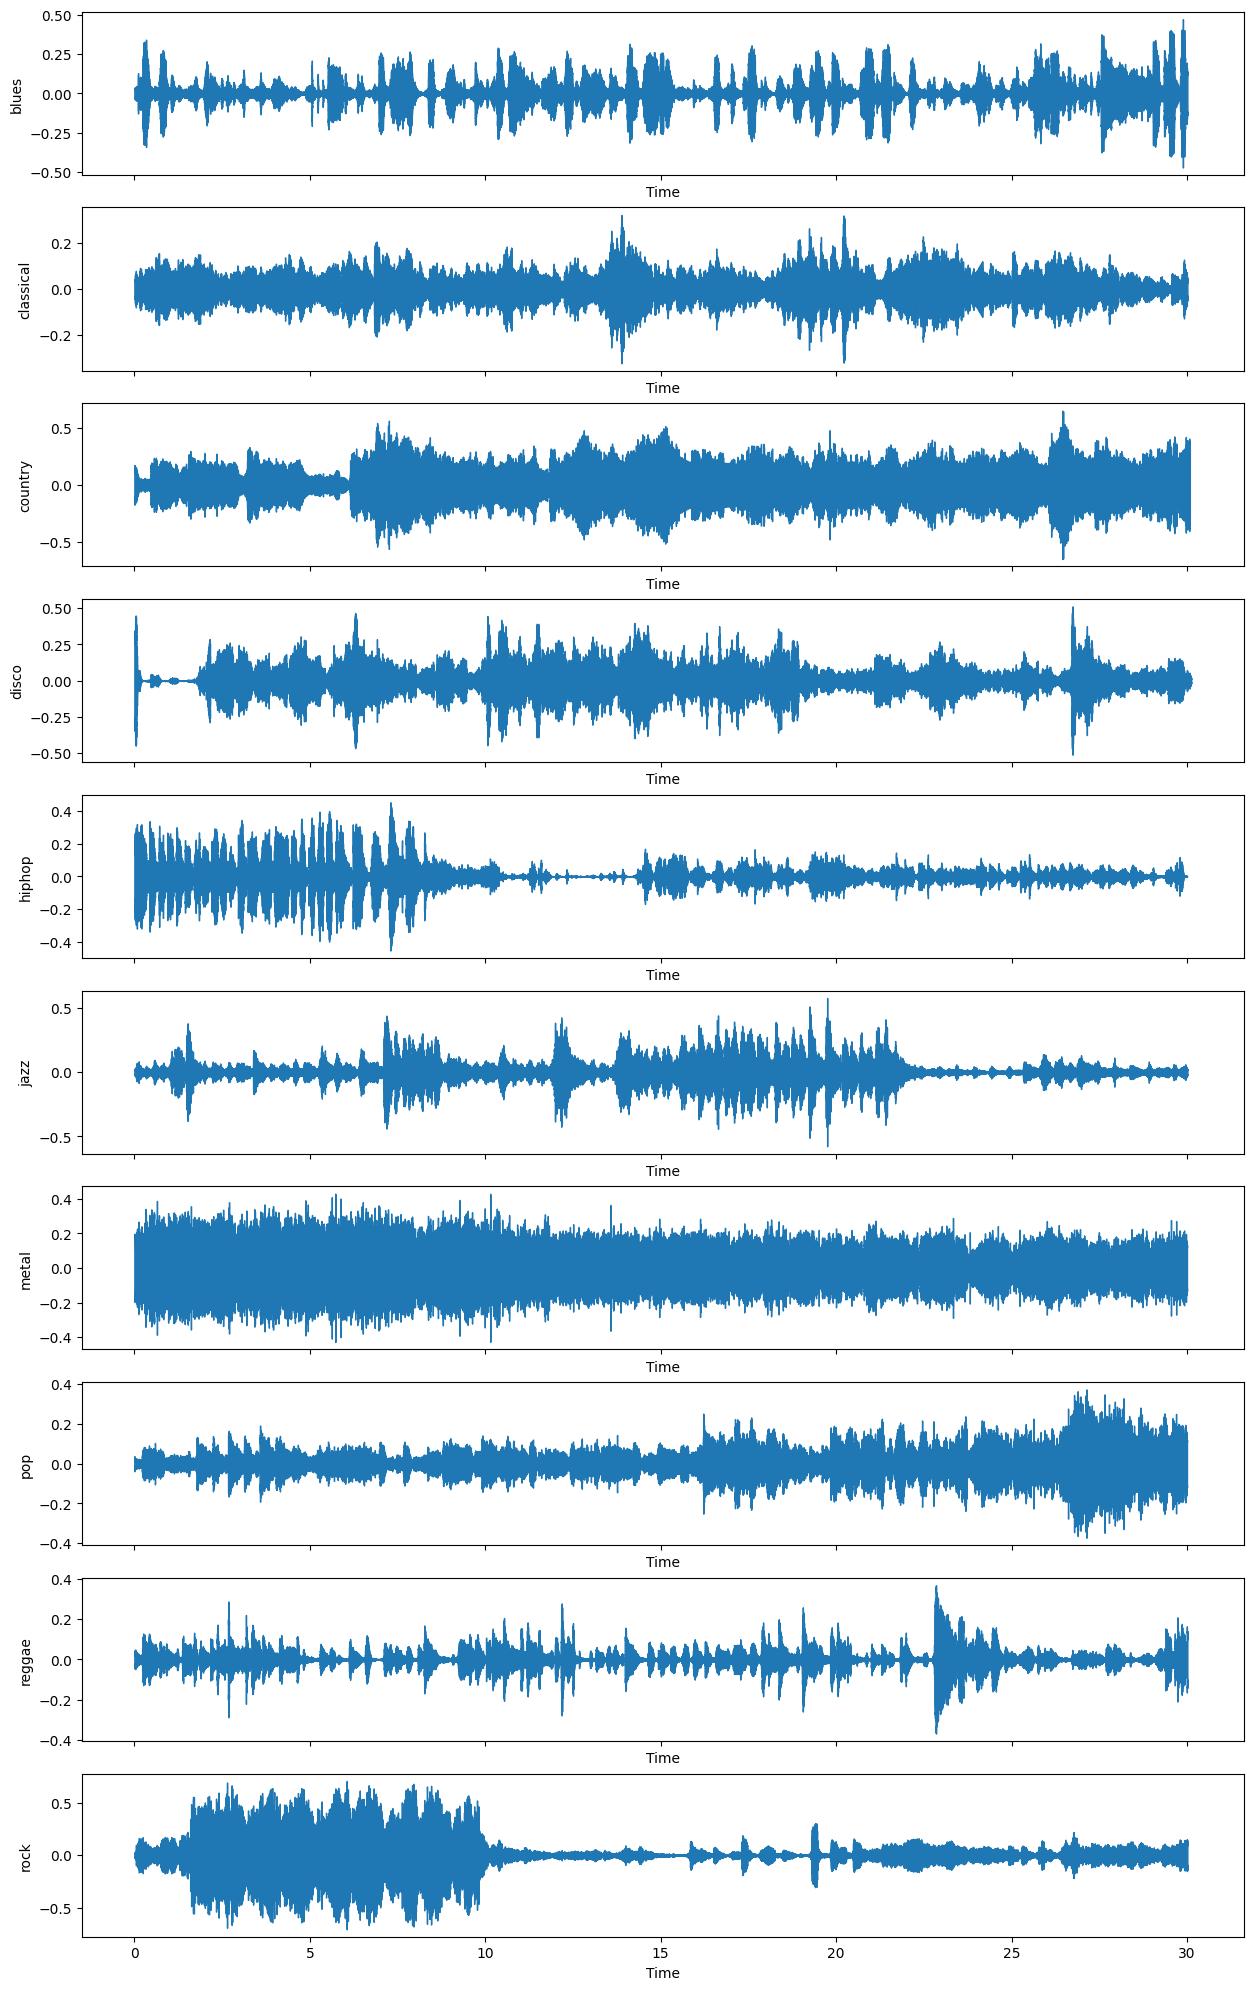

In [28]:
show_wave_form('other')

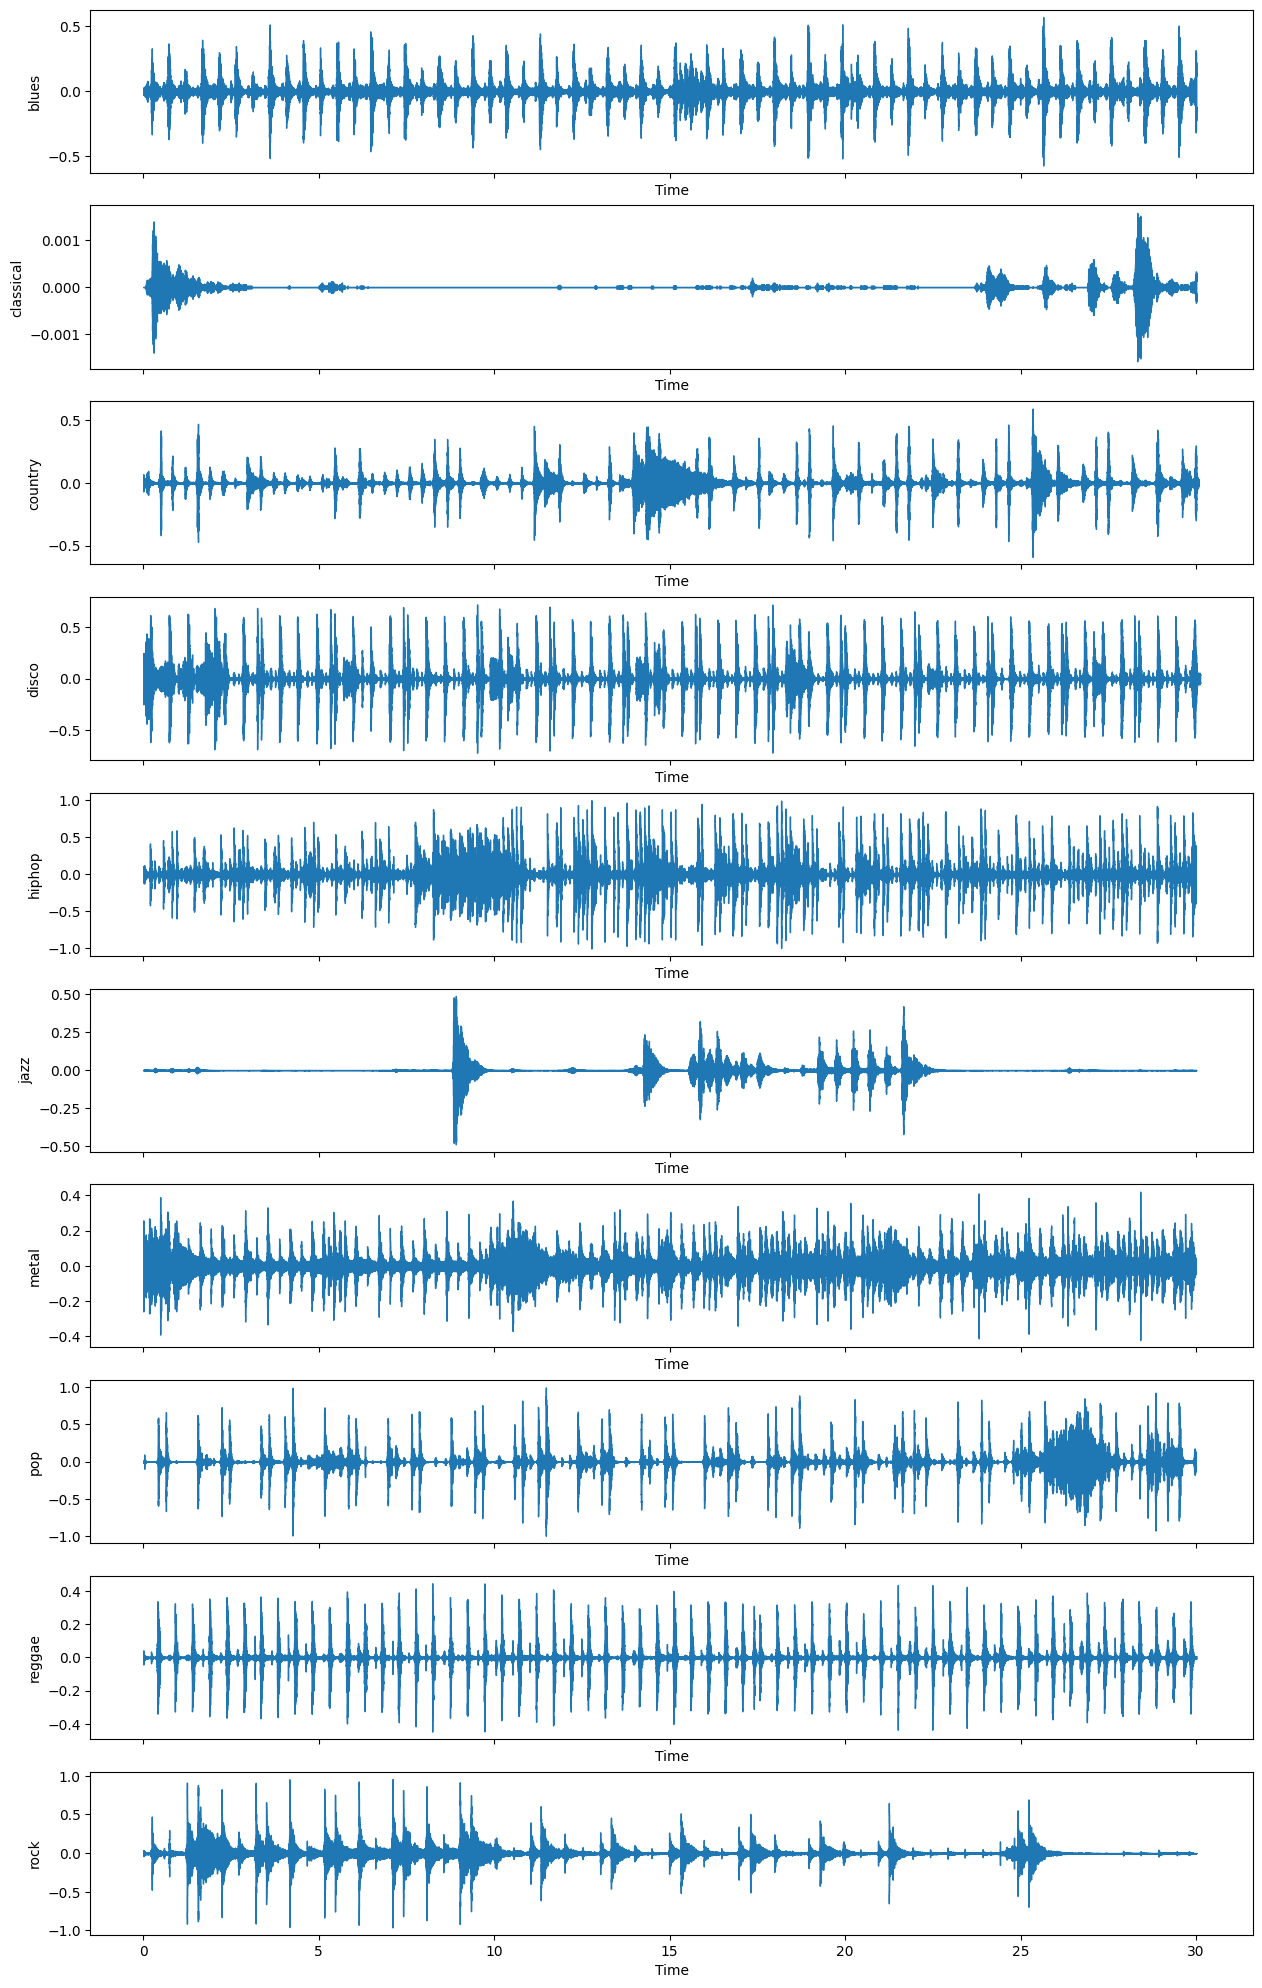

In [29]:
show_wave_form('drums')

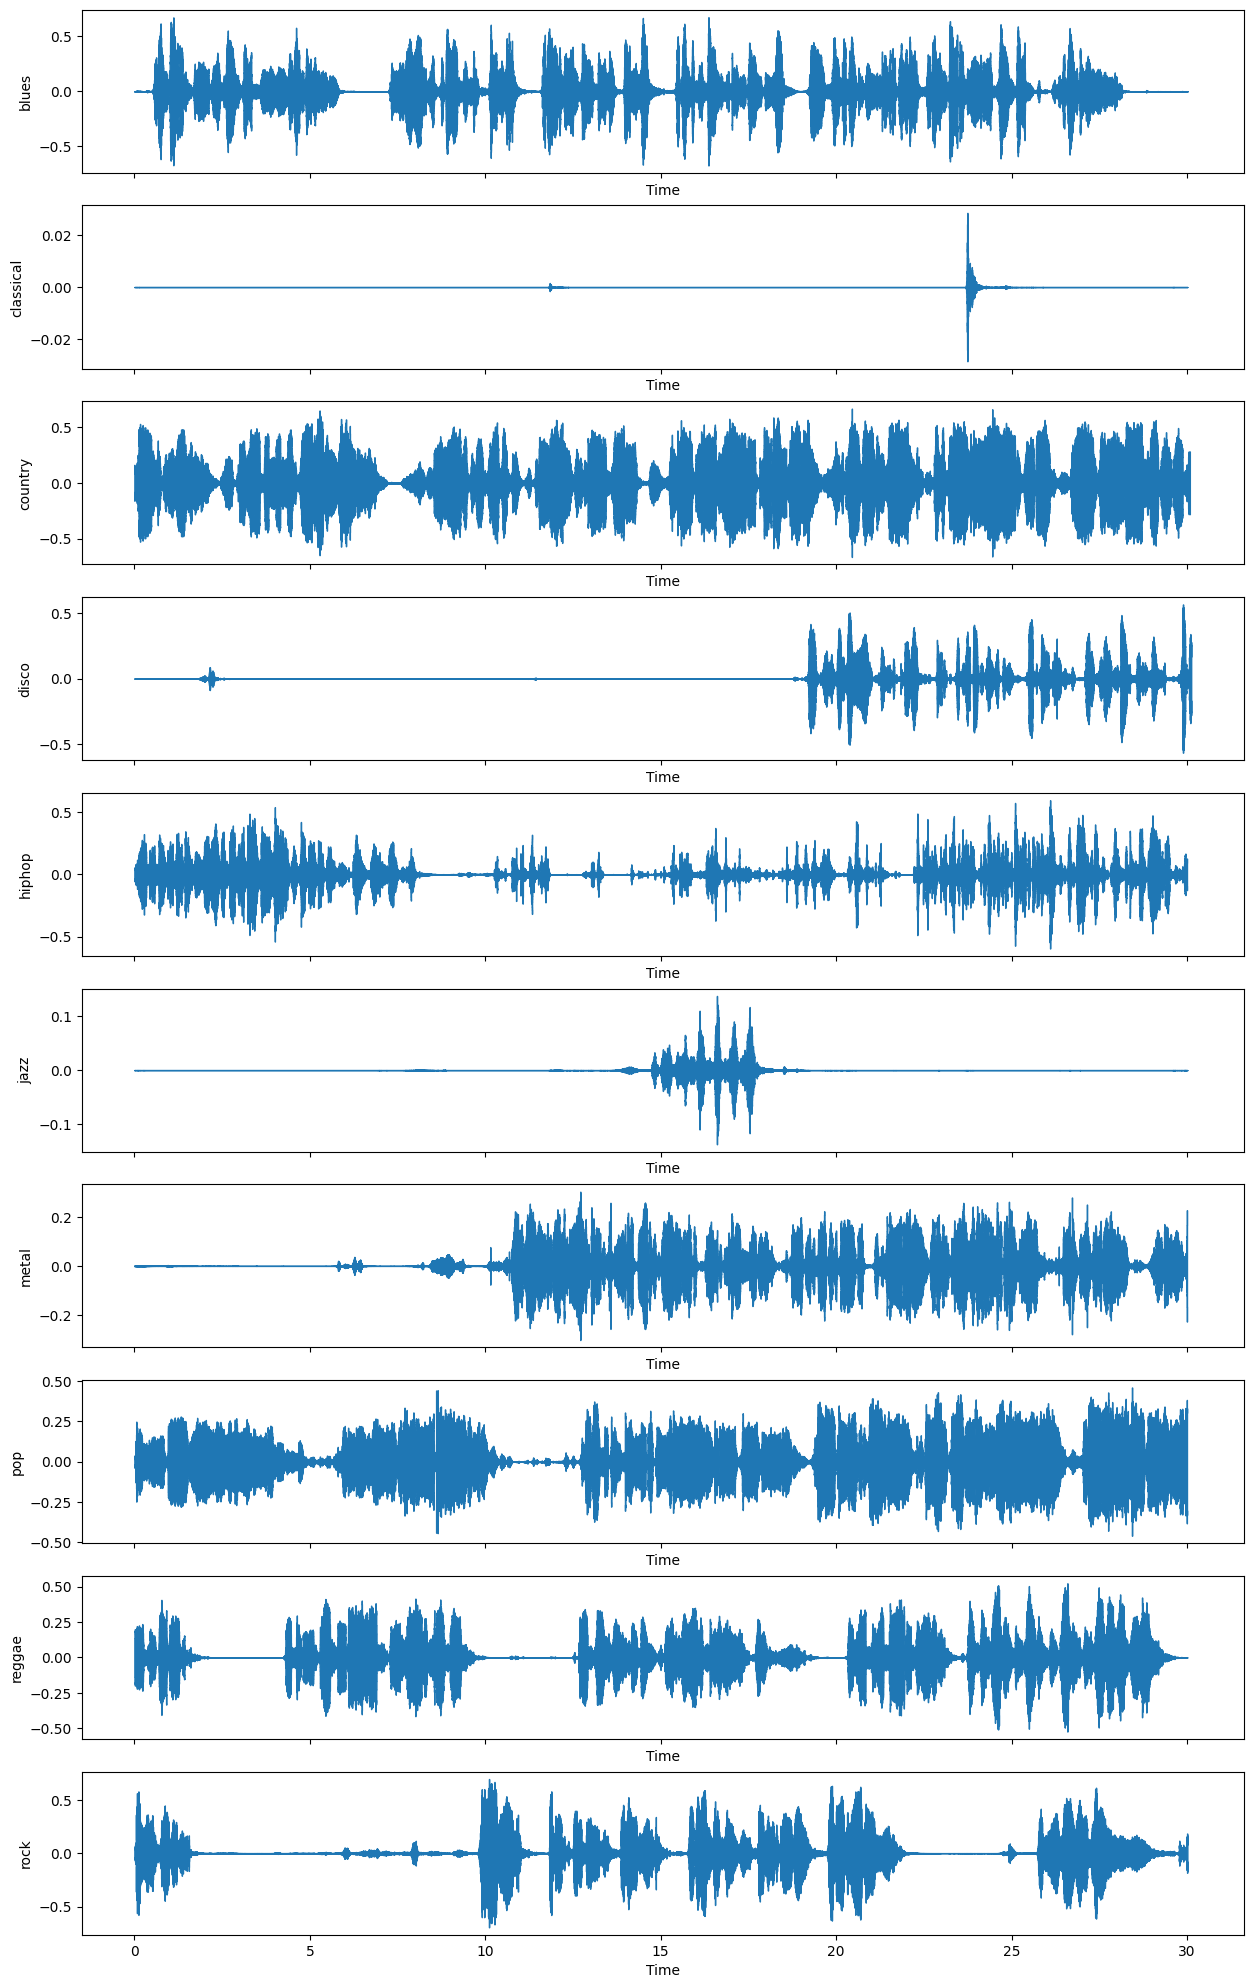

In [30]:
show_wave_form('vocals')

# Noise dataset

In [67]:
root_dir = '/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/'
csv_file = '/meta/esc50.csv'
audio_folder = '/audio/'
file_name = ''
def load_display(file_name):
    y,sr = lb.load(path=root_dir+audio_folder+file_name,sr=None)
    _,ax = plt.subplots(figsize=(6,4))
    lb.display.waveshow(y=y,sr=sr,ax=ax)
    plt.show()
    return Audio(y,rate=sr)
    
df = pd.read_csv(root_dir+csv_file)

In [70]:
df

,filename,fold,target,category,esc10,src_file,take
0,1-100032-A-0.wav,1,0,dog,True,100032,A
1,1-100038-A-14.wav,1,14,chirping_birds,False,100038,A
2,1-100210-A-36.wav,1,36,vacuum_cleaner,False,100210,A
3,1-100210-B-36.wav,1,36,vacuum_cleaner,False,100210,B
4,1-101296-A-19.wav,1,19,thunderstorm,False,101296,A
...,...,...,...,...,...,...,...
1995,5-263831-B-6.wav,5,6,hen,False,263831,B
1996,5-263902-A-36.wav,5,36,vacuum_cleaner,False,263902,A
1997,5-51149-A-25.wav,5,25,footsteps,False,51149,A
1998,5-61635-A-8.wav,5,8,sheep,False,61635,A


In [74]:
# Different noise category
cat = df['category'].unique().tolist()
print(cat)

['dog', 'chirping_birds', 'vacuum_cleaner', 'thunderstorm', 'door_wood_knock', 'can_opening', 'crow', 'clapping', 'fireworks', 'chainsaw', 'airplane', 'mouse_click', 'pouring_water', 'train', 'sheep', 'water_drops', 'church_bells', 'clock_alarm', 'keyboard_typing', 'wind', 'footsteps', 'frog', 'cow', 'brushing_teeth', 'car_horn', 'crackling_fire', 'helicopter', 'drinking_sipping', 'rain', 'insects', 'laughing', 'hen', 'engine', 'breathing', 'crying_baby', 'hand_saw', 'coughing', 'glass_breaking', 'snoring', 'toilet_flush', 'pig', 'washing_machine', 'clock_tick', 'sneezing', 'rooster', 'sea_waves', 'siren', 'cat', 'door_wood_creaks', 'crickets']


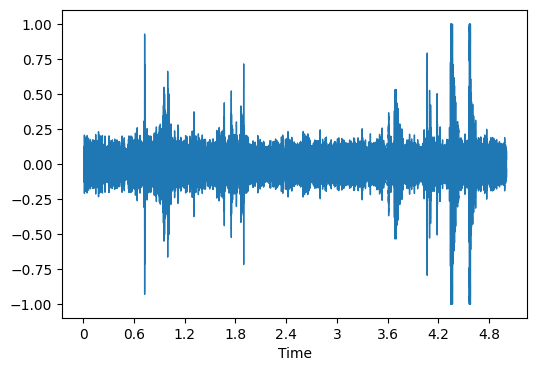

In [81]:
noise = df.loc[df['category']=='drinking_sipping']
file_name = noise.iloc[10]['filename']
load_display(file_name)